# Conditional WGAN-GP
### Butterfly Dataset — 75-class conditional image generation

Implementation details:
- Wasserstein objective with Gradient Penalty (GP) for Lipschitz constraint
- Critic-heavy training (5 iterations per Generator update)
- No batch normalization in Critic to avoid inter-sample dependency in GP
- TTUR (Two Time-Scale Update Rule) for stable convergence


In [16]:
import os, sys
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd

# ── Device Configuration ──────────────────────────────────────────────────
device = torch.device(
    "cuda"  if torch.cuda.is_available()  else
    "mps"   if torch.backends.mps.is_available() else
    "cpu"
)
print(f"Using device: {device}")

Using device: cuda


In [17]:
# ── Project Path Setup ────────────────────────────────────────────────────
sys.path.insert(0, os.path.abspath(".."))

from src.dataset import (
    ButterflyDataset, get_splits, build_label_map,
    get_train_transform, get_eval_transform, make_dataloader,
)
from src.utils import (
    save_checkpoint, load_checkpoint,
    visualize_grid, plot_losses,
    EarlyStopping, tensor_to_pil, denormalize,
)
from src.metrics import compute_fid, compute_inception_score

In [18]:
# ── Hyperparameters and Paths ──────────────────────────────────────────────
BASE_DIR    = os.path.abspath("..")
IMG_DIR     = os.path.join(BASE_DIR, "aca-butterflies", "train")
CSV_PATH    = os.path.join(BASE_DIR, "aca-butterflies", "train.csv")
SAVE_DIR    = os.path.join(BASE_DIR, "data", "generated", "wgan_gp")
NETG_PATH   = os.path.join(BASE_DIR, "saved_models", "wgan_gp_generator.pth")
NETD_PATH   = os.path.join(BASE_DIR, "saved_models", "wgan_gp_critic.pth")
os.makedirs(SAVE_DIR, exist_ok=True)

IMAGE_SIZE  = 64
BATCH_SIZE  = 64
LATENT_DIM  = 100
NUM_CLASSES = 75
EMB_DIM     = 100

NUM_EPOCHS  = 200
SAVE_EVERY  = 20

In [19]:
# ── Dataset Initialization ────────────────────────────────────────────────
label_to_idx, idx_to_label = build_label_map(CSV_PATH)
num_classes = len(label_to_idx)

train_df, val_df, test_df = get_splits(CSV_PATH, train_ratio=0.70, val_ratio=0.15, seed=42)
print(f"Train: {len(train_df):,}  Val: {len(val_df):,}  Test: {len(test_df):,}")

train_set    = ButterflyDataset(train_df, IMG_DIR, label_to_idx,
                                transform=get_train_transform(IMAGE_SIZE))
train_loader = make_dataloader(train_set, BATCH_SIZE, shuffle=True)

Train: 3,606  Val: 745  Test: 848
Batches: 57


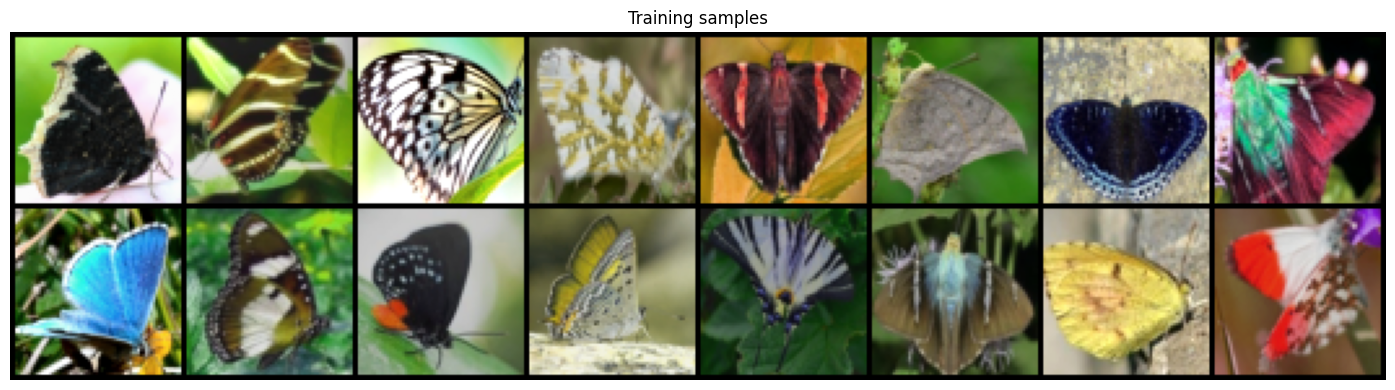

In [20]:
# ── Batch Visualization ───────────────────────────────────────────────────
imgs, labs = next(iter(train_loader))
visualize_grid(imgs, labs, idx_to_label, n=16, nrow=8,
               title="Training samples", denorm=True)

## Model Architecture

### Generator (netG)
Residual-based or ConvTranspose upsampler mapping `noise` + `class embedding` to RGB.

### Critic (netD)
Estimates the Wasserstein distance. Uses InstanceNorm or no normalization
to maintain Gradient Penalty validity.


In [21]:
def weights_init(m):
    """Initialize weights using standard DCGAN/WGAN normal distributions."""
    classname = m.__class__.__name__
    if classname.find("Conv") != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)



In [22]:
class Generator(nn.Module):
    """Conditional Generator: maps latent vector + class index to image space."""

    def __init__(self, latent_dim=LATENT_DIM, num_classes=NUM_CLASSES, emb_dim=EMB_DIM):
        super().__init__()
        self.class_emb = nn.Embedding(num_classes, emb_dim)
        in_ch = latent_dim + emb_dim
        self.main = nn.Sequential(
            nn.ConvTranspose2d(in_ch, 256, 4, 1, 0, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, 4, 2, 1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(True),
            nn.ConvTranspose2d(32, 3, 4, 2, 1, bias=False),
            nn.Tanh(),
        )

    def forward(self, noise, label):
        c = self.class_emb(label).unsqueeze(-1).unsqueeze(-1)
        z = torch.cat([noise, c], dim=1)
        return self.main(z)



In [23]:
class Discriminator(nn.Module):
    """Conditional Critic: estimates Wasserstein score for (image, label) pairs."""

    def __init__(self, num_classes=NUM_CLASSES, emb_dim=EMB_DIM, image_size=IMAGE_SIZE):
        super().__init__()
        self.image_size = image_size
        
        self.class_proj = nn.Sequential(
            nn.Embedding(num_classes, emb_dim),
            nn.Linear(emb_dim, image_size * image_size),
        )
        
        self.model = nn.Sequential(
            nn.Conv2d(4, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(512, 1, 4, 1, 0, bias=False),
        )

    def forward(self, img, label):
        B = img.size(0)
        c = self.class_proj(label).view(B, 1, self.image_size, self.image_size)
        x = torch.cat([img, c], dim=1)
        return self.model(x).view(B)

In [24]:
def compute_gradient_penalty(netD, real_samples, fake_samples, labels, device):
    """Enforce 1-Lipschitz continuity via L2 norm of gradients on interpolated samples."""
    alpha = torch.rand(real_samples.size(0), 1, 1, 1, device=device)
    interpolates = (alpha * real_samples + ((1 - alpha) * fake_samples)).requires_grad_(True)
    
    d_interpolates = netD(interpolates, labels)
    fake = torch.ones(real_samples.size(0), device=device)
    
    gradients = torch.autograd.grad(
        outputs=d_interpolates,
        inputs=interpolates,
        grad_outputs=fake,
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]
    
    gradients = gradients.view(gradients.size(0), -1)
    gradient_penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean()
    return gradient_penalty

In [ ]:
# ── Model Initialization and Optimizers ──────────────────────────────────
netG = Generator(LATENT_DIM, NUM_CLASSES, EMB_DIM).to(device)
netD = Discriminator(NUM_CLASSES, EMB_DIM, IMAGE_SIZE).to(device)
netG.apply(weights_init)
netD.apply(weights_init)

LR_D = 0.0004
LR_G = 0.0001
BETAS_WGAN = (0.0, 0.9)

optimizerD = optim.Adam(netD.parameters(), lr=LR_D, betas=BETAS_WGAN)
optimizerG = optim.Adam(netG.parameters(), lr=LR_G, betas=BETAS_WGAN)

CRITIC_ITERATIONS = 5
LAMBDA_GP = 10.0

In [25]:
# ── Training Loop ─────────────────────────────────────────────────────────
G_losses, D_losses = [], []

for epoch in range(NUM_EPOCHS):
    epoch_G, epoch_D = 0.0, 0.0
    
    for i, (data, labels) in enumerate(train_loader):
        real_cpu = data.to(device)
        lbl = labels.to(device)
        batch_size = real_cpu.size(0)

        # ─── Update D (Critic): minimize -D(x) + D(G(z)) + λ*GP ──────────
        netD.zero_grad()
        
        d_real = netD(real_cpu, lbl).mean()
        
        noise = torch.randn(batch_size, LATENT_DIM, 1, 1, device=device)
        fake = netG(noise, lbl)
        d_fake = netD(fake.detach(), lbl).mean()
        
        gp = compute_gradient_penalty(netD, real_cpu, fake.detach(), lbl, device)
        
        errD = -d_real + d_fake + LAMBDA_GP * gp
        errD.backward()
        optimizerD.step()
        
        epoch_D += errD.item()

        # ─── Update G: minimize -D(G(z)) ─────────────────────────────────
        if i % CRITIC_ITERATIONS == 0:
            netG.zero_grad()
            noise = torch.randn(batch_size, LATENT_DIM, 1, 1, device=device)
            fake = netG(noise, lbl)
            errG = -netD(fake, lbl).mean()
            errG.backward()
            optimizerG.step()
            epoch_G += errG.item()

        if i % 50 == 0:
            print(f"[{epoch+1}/{NUM_EPOCHS}][{i}/{len(train_loader)}] "
                  f"Loss_D: {errD.item():.4f}  Loss_G: {errG.item():.4f}  "
                  f"D(x): {d_real.item():.4f}  D(G(z)): {d_fake.item():.4f}")

    num_G_updates = max(1, len(train_loader) // CRITIC_ITERATIONS)
    G_losses.append(epoch_G / num_G_updates)
    D_losses.append(epoch_D / len(train_loader))

    # ── Checkpointing and Periodic Visualization ─────────────────────────
    if (epoch + 1) % SAVE_EVERY == 0 or epoch == NUM_EPOCHS - 1:
        netG.eval()
        with torch.no_grad():
            sample_lbl  = torch.arange(min(16, NUM_CLASSES), device=device)
            noise_fixed = torch.randn(len(sample_lbl), LATENT_DIM, 1, 1, device=device)
            fake_sample = (netG(noise_fixed, sample_lbl).detach().cpu() + 1) * 0.5
            
        grid = make_grid(fake_sample, nrow=8, padding=2)
        plt.figure(figsize=(12, 6))
        plt.imshow(grid.permute(1, 2, 0).numpy())
        plt.axis("off")
        plt.title(f"Epoch {epoch+1}")
        plt.show()
        netG.train()

        save_checkpoint(netG, NETG_PATH, epoch=epoch + 1)
        save_checkpoint(netD, NETD_PATH, epoch=epoch + 1)
        print(f"Checkpoints saved at epoch {epoch+1}")

print("Training complete.")

Generator parameters    : 1,517,324
Discriminator parameters: 3,185,996


[1/200][0/57] Loss_D: 9.1722  Loss_G: -0.0518  D(x): 0.0078  D(G(z)): -0.0033
[1/200][50/57] Loss_D: -100.1470  Loss_G: -12.8626  D(x): 206.4432  D(G(z)): 19.2239
[2/200][0/57] Loss_D: -100.1250  Loss_G: -20.9213  D(x): 143.1657  D(G(z)): 16.6440
[2/200][50/57] Loss_D: -105.5973  Loss_G: -15.4190  D(x): 237.8301  D(G(z)): 32.9688
[3/200][0/57] Loss_D: -92.6135  Loss_G: -30.9033  D(x): 129.9686  D(G(z)): 17.0512
[3/200][50/57] Loss_D: -78.1298  Loss_G: -32.9776  D(x): 98.3959  D(G(z)): 12.4992
[4/200][0/57] Loss_D: -79.4824  Loss_G: -17.6637  D(x): 181.1764  D(G(z)): 38.9501
[4/200][50/57] Loss_D: -80.5826  Loss_G: -25.9928  D(x): 202.0006  D(G(z)): 48.7375
[5/200][0/57] Loss_D: -69.3294  Loss_G: -36.8097  D(x): 148.8377  D(G(z)): 38.8722
[5/200][50/57] Loss_D: -86.2775  Loss_G: -46.8431  D(x): 182.9237  D(G(z)): 51.1702
[6/200][0/57] Loss_D: -75.7995  Loss_G: -50.1915  D(x): 154.2289  D(G(z)): 44.2813
[6/200][50/57] Loss_D: -71.8861  Loss_G: -22.1557  D(x): 201.6234  D(G(z)): 64.4505
[

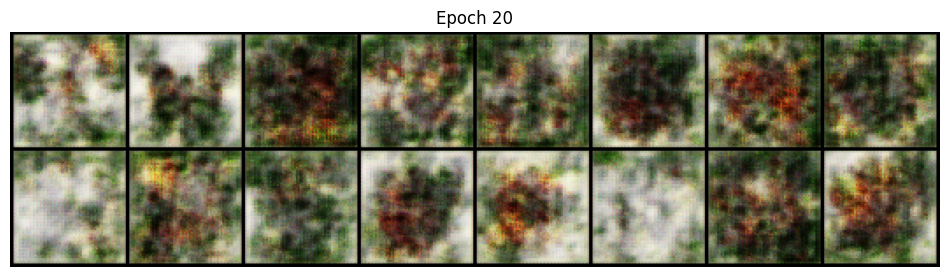

[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\wgan_gp_generator.pth
[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\wgan_gp_critic.pth
Checkpoints saved at epoch 20
[21/200][0/57] Loss_D: -23.3628  Loss_G: -14.4125  D(x): 56.0150  D(G(z)): 21.1405
[21/200][50/57] Loss_D: -30.7754  Loss_G: -26.8059  D(x): 61.1578  D(G(z)): 22.2963
[22/200][0/57] Loss_D: -23.3469  Loss_G: -22.7202  D(x): 59.2960  D(G(z)): 28.1249
[22/200][50/57] Loss_D: -20.8463  Loss_G: -17.5409  D(x): 44.0199  D(G(z)): 16.7977
[23/200][0/57] Loss_D: -19.1032  Loss_G: -32.1679  D(x): 37.7704  D(G(z)): 17.0300
[23/200][50/57] Loss_D: -18.6382  Loss_G: -21.5320  D(x): 69.8384  D(G(z)): 40.6231
[24/200][0/57] Loss_D: -17.0274  Loss_G: -19.2315  D(x): 68.1015  D(G(z)): 40.3384
[24/200][50/57] Loss_D: -25.9149  Loss_G: -42.8384  D(x): 61.6004  D(G(z)): 29.7704
[25/200][0/57] Loss_D: -20.0785  Loss_G: -33.7721  D(x): 49.0866  D(G(z)): 25.7807
[25/200][50/57] Loss_D: -21.3963  

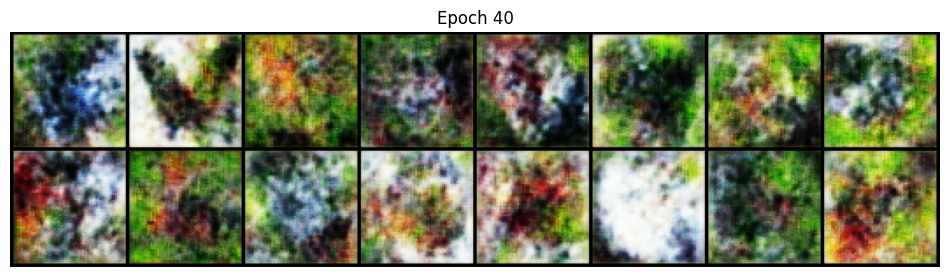

[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\wgan_gp_generator.pth
[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\wgan_gp_critic.pth
Checkpoints saved at epoch 40
[41/200][0/57] Loss_D: -18.4704  Loss_G: -23.6704  D(x): 46.2878  D(G(z)): 22.6075
[41/200][50/57] Loss_D: -16.9169  Loss_G: -19.6796  D(x): 33.1440  D(G(z)): 13.2002
[42/200][0/57] Loss_D: -14.5247  Loss_G: -17.3691  D(x): 52.6416  D(G(z)): 32.4412
[42/200][50/57] Loss_D: -17.9947  Loss_G: -18.3892  D(x): 44.7034  D(G(z)): 22.2110
[43/200][0/57] Loss_D: -13.1927  Loss_G: -16.5474  D(x): 38.5669  D(G(z)): 19.1424
[43/200][50/57] Loss_D: -17.2053  Loss_G: -22.5487  D(x): 41.6931  D(G(z)): 20.5768
[44/200][0/57] Loss_D: -16.2742  Loss_G: -25.5557  D(x): 31.0085  D(G(z)): 13.2147
[44/200][50/57] Loss_D: -15.1853  Loss_G: -18.4187  D(x): 34.0115  D(G(z)): 15.2848
[45/200][0/57] Loss_D: -14.9909  Loss_G: -21.7602  D(x): 42.2805  D(G(z)): 23.2700
[45/200][50/57] Loss_D: -17.3617  

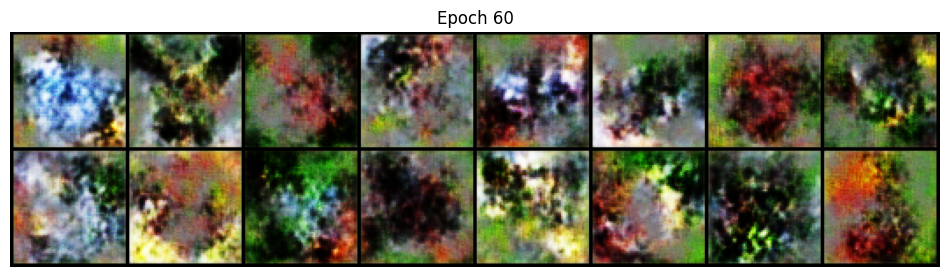

[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\wgan_gp_generator.pth
[checkpoint] saved → c:\Users\ricar\Downloads\TP2-Students\saved_models\wgan_gp_critic.pth
Checkpoints saved at epoch 60
[61/200][0/57] Loss_D: -15.0061  Loss_G: -23.0470  D(x): 57.1711  D(G(z)): 36.9599
[61/200][50/57] Loss_D: -16.3109  Loss_G: -9.2191  D(x): 44.6679  D(G(z)): 23.0845
[62/200][0/57] Loss_D: -17.4292  Loss_G: -25.3774  D(x): 48.5449  D(G(z)): 25.2754
[62/200][50/57] Loss_D: -18.0468  Loss_G: -28.3290  D(x): 44.0066  D(G(z)): 22.0357
[63/200][0/57] Loss_D: -13.9941  Loss_G: -17.8280  D(x): 36.0064  D(G(z)): 18.9904
[63/200][50/57] Loss_D: -17.2103  Loss_G: -31.1984  D(x): 36.4842  D(G(z)): 16.1266
[64/200][0/57] Loss_D: -18.6850  Loss_G: -27.4976  D(x): 36.9216  D(G(z)): 14.1280
[64/200][50/57] Loss_D: -15.5822  Loss_G: -26.4739  D(x): 50.6591  D(G(z)): 30.7306
[65/200][0/57] Loss_D: -17.1312  Loss_G: -12.8929  D(x): 42.1642  D(G(z)): 20.7753


In [ ]:
# ── Evaluation: Loss Curves ──────────────────────────────────────────────
plt.figure(figsize=(10, 5))
plt.plot(G_losses, label="Generator")
plt.plot(D_losses, label="Discriminator (Critic)")
plt.title("WGAN-GP Training Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

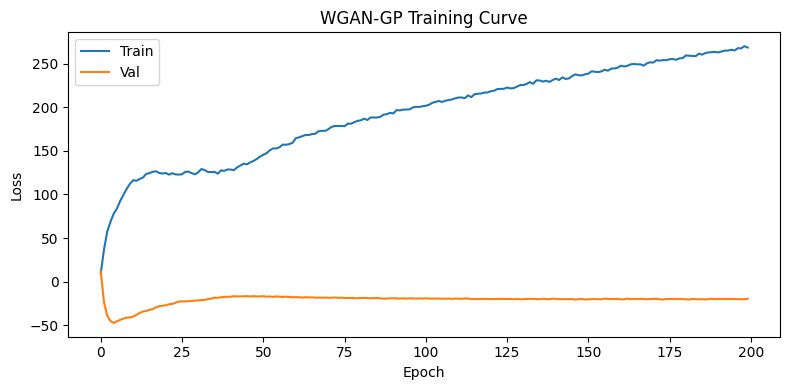

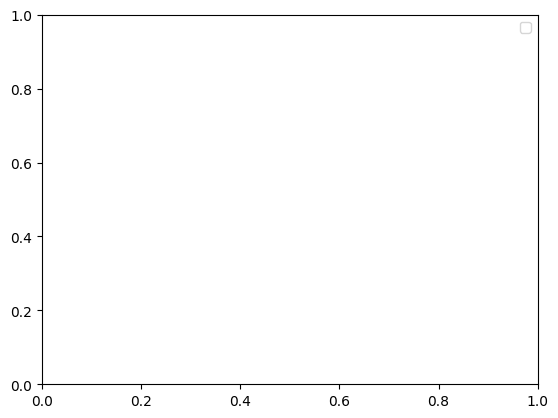

In [ ]:
# ── Sample Generation and Dataset Balancing ───────────────────────────────
load_checkpoint(NETG_PATH, netG, device)
netG = netG.to(device)
netG.eval()

class_counts = Counter(train_df["label"].tolist())
TARGET_PER_CLASS = max(class_counts.values())

generated_records = []
with torch.no_grad():
    for class_name, class_idx in label_to_idx.items():
        existing = class_counts.get(class_name, 0)
        n_gen = max(0, TARGET_PER_CLASS - existing)
        if n_gen == 0:
            continue

        all_gen = []
        remaining = n_gen
        while remaining > 0:
            batch_n = min(remaining, BATCH_SIZE)
            noise = torch.randn(batch_n, LATENT_DIM, 1, 1, device=device)
            lbl   = torch.full((batch_n,), class_idx, dtype=torch.long, device=device)
            gen   = netG(noise, lbl).cpu()
            all_gen.append(gen)
            remaining -= batch_n

        gen_imgs = torch.cat(all_gen, dim=0)
        gen_imgs = (gen_imgs * 0.5 + 0.5).clamp(0, 1)

        for j, img_t in enumerate(gen_imgs):
            fname = f"wgan_gp_{class_idx:03d}_{j:04d}.jpg"
            tensor_to_pil(img_t).save(os.path.join(SAVE_DIR, fname))
            generated_records.append({
                "filename": fname,
                "label": class_name,
                "img_dir": SAVE_DIR,
            })

        print(f"  [{class_idx:02d}] {class_name}: generated {n_gen}")

gen_df = pd.DataFrame(generated_records)
gen_df.to_csv(os.path.join(SAVE_DIR, "generated.csv"), index=False)
print(f"\nTotal generated: {len(gen_df):,}  |  CSV saved.")

In [ ]:
# ── Generate images per class to balance the dataset ──────────────────────
load_checkpoint(NETG_PATH, netG, device)
netG = netG.to(device)
netG.eval()

class_counts = Counter(train_df["label"].tolist())
TARGET_PER_CLASS = max(class_counts.values())

generated_records = []
with torch.no_grad():
    for class_name, class_idx in label_to_idx.items():
        existing = class_counts.get(class_name, 0)
        n_gen = max(0, TARGET_PER_CLASS - existing)
        if n_gen == 0:
            continue

        all_gen = []
        remaining = n_gen
        while remaining > 0:
            batch_n = min(remaining, BATCH_SIZE)
            noise = torch.randn(batch_n, LATENT_DIM, 1, 1, device=device)
            lbl   = torch.full((batch_n,), class_idx, dtype=torch.long, device=device)
            gen   = netG(noise, lbl).cpu()        # (batch_n, 3, 64, 64) in [-1,1]
            all_gen.append(gen)
            remaining -= batch_n

        gen_imgs = torch.cat(all_gen, dim=0)      # (n_gen, 3, 64, 64)
        gen_imgs = (gen_imgs * 0.5 + 0.5).clamp(0, 1)   # → [0,1]

        for j, img_t in enumerate(gen_imgs):
            fname = f"wgan_gp_{class_idx:03d}_{j:04d}.jpg"
            tensor_to_pil(img_t).save(os.path.join(SAVE_DIR, fname))
            generated_records.append({
                "filename": fname,
                "label": class_name,
                "img_dir": SAVE_DIR,
            })

        print(f"  [{class_idx:02d}] {class_name}: generated {n_gen}")

gen_df = pd.DataFrame(generated_records)
gen_df.to_csv(os.path.join(SAVE_DIR, "generated.csv"), index=False)
print(f"\nTotal generated: {len(gen_df):,}  |  CSV saved.")

[checkpoint] loaded ← c:\Users\ricar\Downloads\TP2-Students\saved_models\wgan_gp_generator.pth
  [00] ADONIS: generated 24
  [01] AFRICAN GIANT SWALLOWTAIL: generated 31
  [02] AMERICAN SNOOT: generated 32
  [03] AN 88: generated 26
  [04] APPOLLO: generated 23
  [05] ATALA: generated 17
  [06] BANDED ORANGE HELICONIAN: generated 20
  [07] BANDED PEACOCK: generated 27
  [08] BECKERS WHITE: generated 28
  [09] BLACK HAIRSTREAK: generated 26
  [10] BLUE MORPHO: generated 31
  [11] BLUE SPOTTED CROW: generated 25
  [12] BROWN SIPROETA: generated 18
  [13] CABBAGE WHITE: generated 23
  [14] CAIRNS BIRDWING: generated 27
  [15] CHECQUERED SKIPPER: generated 20
  [16] CHESTNUT: generated 26
  [17] CLEOPATRA: generated 22
  [18] CLODIUS PARNASSIAN: generated 24
  [19] CLOUDED SULPHUR: generated 22
  [20] COMMON BANDED AWL: generated 24
  [21] COMMON WOOD-NYMPH: generated 23
  [22] COPPER TAIL: generated 21
  [23] CRECENT: generated 20
  [24] CRIMSON PATCH: generated 33
  [25] DANAID EGGFLY: g

## Evaluation of Generative Quality

FID and IS computed globally (all classes) — same protocol as the cVAE notebook.
SSIM is omitted for GANs (outputs are not reconstruction-paired with real images).


In [ ]:
def collect_tensor(loader):
    batches = [imgs for imgs, _ in loader]
    return torch.cat(batches, dim=0)

print("Collecting real images…")
real_imgs = collect_tensor(train_loader)

print("Collecting WGAN-GP-generated images…")
gen_set  = ButterflyDataset(gen_df, SAVE_DIR, label_to_idx,
                             transform=get_eval_transform(IMAGE_SIZE))
gen_dl   = make_dataloader(gen_set, BATCH_SIZE, shuffle=False)
gen_imgs = collect_tensor(gen_dl)

print(f"Real: {real_imgs.shape}  |  Generated: {gen_imgs.shape}")

Real: torch.Size([3606, 3, 64, 64])  |  Generated: torch.Size([1869, 3, 64, 64])


In [ ]:
print("Computing FID…")
fid_score = compute_fid(real_imgs, gen_imgs, device=device)
print(f"FID: {fid_score:.2f}  (lower is better)")

print("Computing IS…")
is_mean, is_std = compute_inception_score(gen_imgs, device=device)
print(f"IS:  {is_mean:.3f} ± {is_std:.3f}  (higher is better)")

print("\n=== WGAN-GP Generative Quality Summary ===")
print(f"  FID : {fid_score:.2f}")
print(f"  IS  : {is_mean:.3f} ± {is_std:.3f}")

Computing FID…
FID: 210.41  (lower is better)
Computing IS…
IS:  2.166 ± 0.180  (higher is better)

=== WGAN-GP Generative Quality Summary ===
  FID : 210.41
  IS  : 2.166 ± 0.180
